# **Beer sound analysis**

This code analyzes the sound measurements made by beer (in our case, mostly non-alcoholic) poured into a glass.

Our research aims to analyze whether density affects the pitch of the sound in a similar way to volume.

## Imports

Note that the "functions" import (from functions.py) uses also PyAV, Numpy, Glob, Scipy and Pandas. You may need to install them before the first run

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from functions import load_all, dominant_frequencies, plot_spectrum

NOTEBOOK_DIR = os.path.join(os.getcwd(), "DIR")
beer_folders = [d for d in os.listdir(NOTEBOOK_DIR) if os.path.isdir(os.path.join(NOTEBOOK_DIR, d))]

print(f"Found beer's folders: {beer_folders}\n" + "-"*40)

Found beer's folders: ['Okocim-wisnia', 'Kasztelan', 'Mamrot', 'Żywiec']
----------------------------------------


## Reading sound files

Our recordings are in .wav format. Therefore, we also manually analyzed the audio using Friture. These results will be published in the future.


Starts an analysis for: OKOCIM-WISNIA
Loaded: okocim-wisnia-20_cut.wav | 44100 Hz | 1.49s
Loaded: okocim-wisnia-30_cut.wav | 44100 Hz | 1.24s
Loaded: okocim-wisnia-40_cut.wav | 384000 Hz | 1.77s
Loaded: okocim-wisnia-50_cut.wav | 384000 Hz | 2.27s
Loaded: okocim-wisnia-60_cut.wav | 44100 Hz | 1.89s
Loaded: okocim-wisnia-70_cut.wav | 44100 Hz | 1.89s
Loaded: okocim-wisnia-80_cut.wav | 44100 Hz | 1.54s
Loaded: okocim-wisnia-90_cut.wav | 44100 Hz | 1.20s


frequencies,volume
1295.838266,20
1295.349731,30
1288.738682,40
1277.449804,50
1267.308339,60
1247.195858,70
1218.863810,80
1180.951930,90


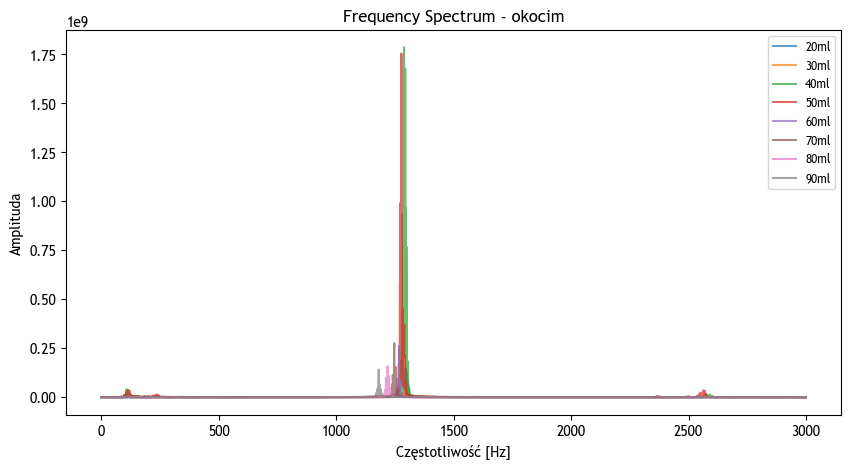


Starts an analysis for: KASZTELAN
Loaded: kasztelan-20_cut.wav | 384000 Hz | 1.10s
Loaded: kasztelan-30_cut.wav | 384000 Hz | 1.05s
Loaded: kasztelan-40_cut.wav | 384000 Hz | 1.02s
Loaded: kasztelan-50_cut.wav | 384000 Hz | 0.96s
Loaded: kasztelan-60_cut.wav | 384000 Hz | 1.00s
Loaded: kasztelan-70_cut.wav | 384000 Hz | 0.99s
Loaded: kasztelan-80_cut.wav | 384000 Hz | 0.96s
Loaded: kasztelan-90_cut.wav | 384000 Hz | 1.27s


frequencies,volume
1297.918894,20
1294.709578,30
1289.719341,40
1279.874931,50
1268.994033,60
1249.347063,70
1224.307054,80
1188.523735,90


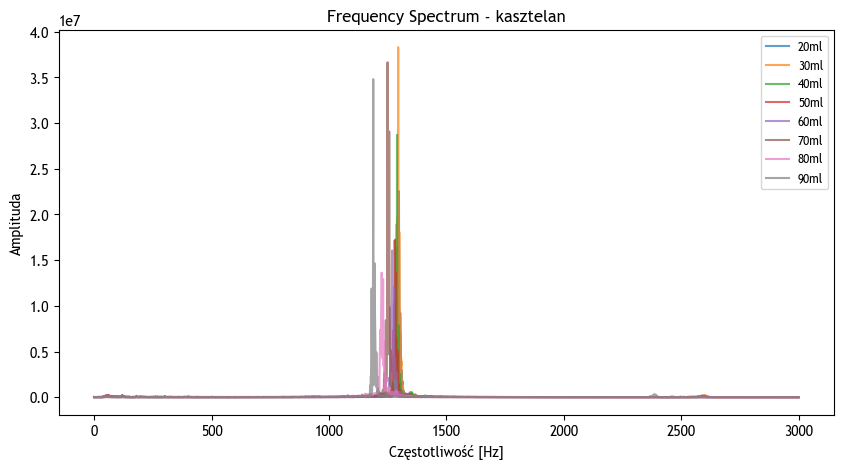


Starts an analysis for: MAMROT
Loaded: mamrot-20_cut.wav | 384000 Hz | 1.45s
Loaded: mamrot-30_cut.wav | 384000 Hz | 1.23s
Loaded: mamrot-40_cut.wav | 384000 Hz | 1.01s
Loaded: mamrot-50_cut.wav | 384000 Hz | 1.22s
Loaded: mamrot-60_cut.wav | 384000 Hz | 1.17s
Loaded: mamrot-70_cut.wav | 384000 Hz | 1.50s
Loaded: mamrot-80_cut.wav | 384000 Hz | 1.40s
Loaded: mamrot-90_cut.wav | 384000 Hz | 1.51s


frequencies,volume
1303.007374,20
1294.856604,30
1294.511830,40
1287.159103,50
1276.800192,60
1258.182160,70
1234.566066,80
1200.540691,90


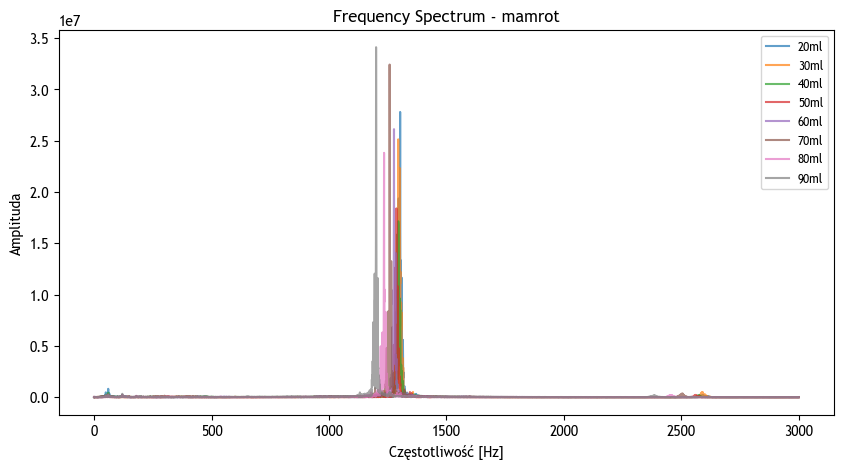


Starts an analysis for: ŻYWIEC
Loaded: zywiec-20_cut.wav | 384000 Hz | 1.47s
Loaded: zywiec-30_cut.wav | 384000 Hz | 1.08s
Loaded: zywiec-40_cut.wav | 384000 Hz | 1.33s
Loaded: zywiec-50_cut.wav | 384000 Hz | 1.44s
Loaded: zywiec-60_cut.wav | 384000 Hz | 1.34s
Loaded: zywiec-70_cut.wav | 384000 Hz | 1.46s
Loaded: zywiec-80_cut.wav | 384000 Hz | 1.29s
Loaded: zywiec-90_cut.wav | 384000 Hz | 1.43s


frequencies,volume
1303.445234,20
1301.056780,30
1294.209896,40
1288.276156,50
1277.065594,60
1257.468076,70
1231.938610,80
1196.499835,90


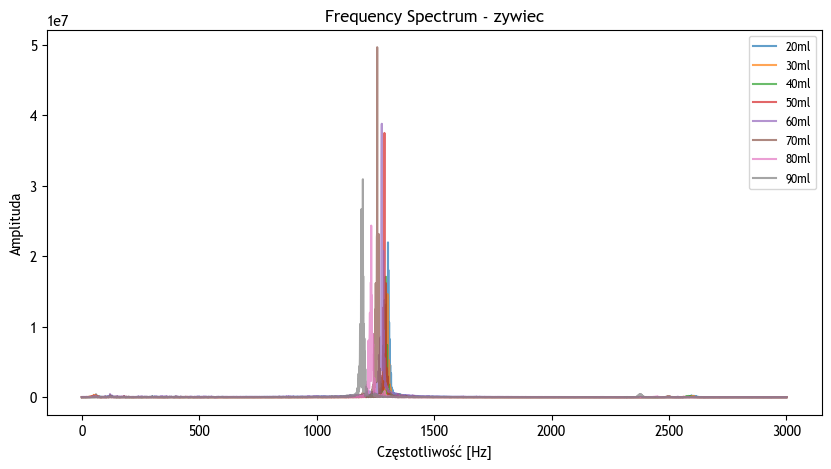

In [8]:

all_results = []

for beer in beer_folders:
    print(f"\nStarts an analysis for: {beer.upper()}")
    folder_path = os.path.join(NOTEBOOK_DIR, beer)
    
    recordings = load_all(folder_path)
    
    if not recordings:
        print(f"Skipped {beer} - no audio files found.")
        continue
        
    beer_res, fft_data = dominant_frequencies(recordings)

    all_results.append(beer_res)
    display(beer_res.drop(columns='Beer').style.hide(axis='index').set_caption(f"Results for {beer_res['Beer'].iloc[0]}:"))
    plot_spectrum(fft_data, beer_res)

#### Results

Plot of combined results

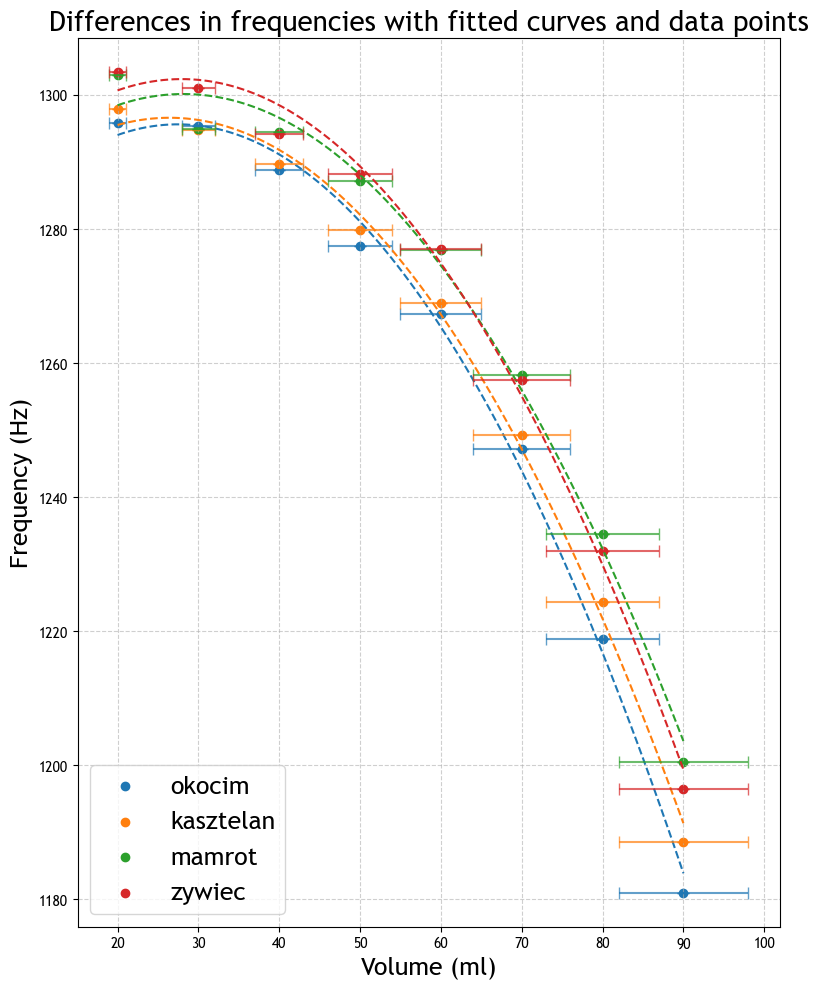

In [9]:

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Trebuchet MS']

plt.figure(figsize=(8, 10)) 

for df in all_results:
    beer_name = df['Beer'].iloc[0]
    volumes = df['volume']
    frequencies = df['frequencies']
    
    err_vol = np.arange(1, len(volumes) + 1)
    err_freq = 0
    
    scatter_plot = plt.scatter(volumes, frequencies, label=f'{beer_name}')
    current_color = scatter_plot.get_facecolor()[0]

    plt.errorbar(
        volumes, frequencies, 
        xerr=err_vol, yerr=err_freq, 
        fmt='none', ecolor=current_color, capsize=4, alpha=0.7
    ) 

    if len(volumes) > 2: 
        z = np.polyfit(volumes, frequencies, 2)
        p = np.poly1d(z)
        xp = np.linspace(volumes.min(), volumes.max(), 100)
        plt.plot(xp, p(xp), linestyle='--', color=current_color)
    elif len(volumes) > 1: 
        z = np.polyfit(volumes, frequencies, 1)
        p = np.poly1d(z)
        xp = np.linspace(volumes.min(), volumes.max(), 100)
        plt.plot(xp, p(xp), linestyle='--', color=current_color)
    else:
        print(f"Za mało punktów dla {beer_name} do dopasowania krzywej.")

size=18

plt.title('Differences in frequencies with fitted curves and data points', fontsize=size+2, loc='center')
plt.xlabel("Volume (ml)", fontsize=size, loc='center')
plt.ylabel("Frequency (Hz)", fontsize=size, loc='center')

f_min = [df['frequencies'].min() for df in all_results]
f_max = [df['frequencies'].max() for df in all_results]

plt.ylim(min(f_min)-5, max(f_max)+5) 
plt.legend(loc='lower left', prop={'size': size}) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()